# Imports

In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Handling imbalance
from sklearn.utils import resample

# display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

---

# Load Data

In [2]:
raw_df = pd.read_csv("online_shoppers_intention.csv")

display(raw_df.head())
display(raw_df.shape)
display(raw_df.columns)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


(12330, 18)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

### Load Data

#### Dataset structure
- 12,330 rows and 18 columns.
- Each row is a single online shopping session.
- `Revenue` is the target variable.

#### Feature types
- Mixture of:
    - continuous variables
    - count variables
    - binary variables
    - coded categorical variables

#### Session framing
- This is a session level classification task.
- We are looking for browsing behavior associated with purchase outcomes.

#### Pre-processing implications
- Numeric and categorical variables will need separate handling later.
    - `Month`, `VisitorType`, `Weekend` are categorical.
- Some numeric-coded predictors may be better treated as categorical.
  - `SpecialDay`, `Browser`, `OperatingSystems`, `TrafficType`, and `Region` are numeric-coded categories

### We would like to look into 
1. Target Balance
2. Correlation heatmap
3. Behavioral differences with the target
4. Distribution shapes and zero inflation (transformations if needed)
5. Numerical variables distributions
6. Categorical variables 
7. Month based differences for seasonal trends (as well as special days)

> Source: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

---

# EDA:

### Target Variable Analysis

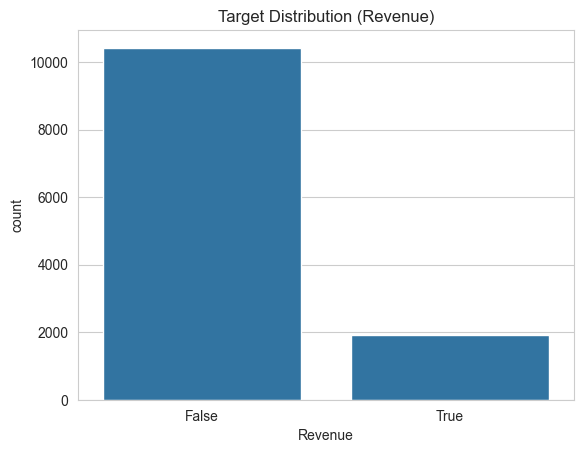

,Percentage,Count
Revenue,,
False,84.525547,10422
True,15.474453,1908


In [3]:
# Target Distribution
sns.countplot(x='Revenue', data=raw_df)
plt.title("Target Distribution (Revenue)")
plt.show()

# table
raw_target_distribution_table = pd.DataFrame({
    'Percentage': raw_df['Revenue'].value_counts(normalize=True) * 100,
    'Count': raw_df['Revenue'].value_counts()
})

raw_target_distribution_table

### Revenue Distribution:
- Class balance
    - 10,422 (84.5%) vs 1,908 (15.5%)
- Metric choice
    - Accuracy could mislead due to imbalance. Model predicting mostly "False" could appear 'good'.
    - Other metrics like F1, recall, ROC-AUC would suffice
##### Pre-processing decisions
- Stratified train/validate/test split to keep proportions similar across splits.

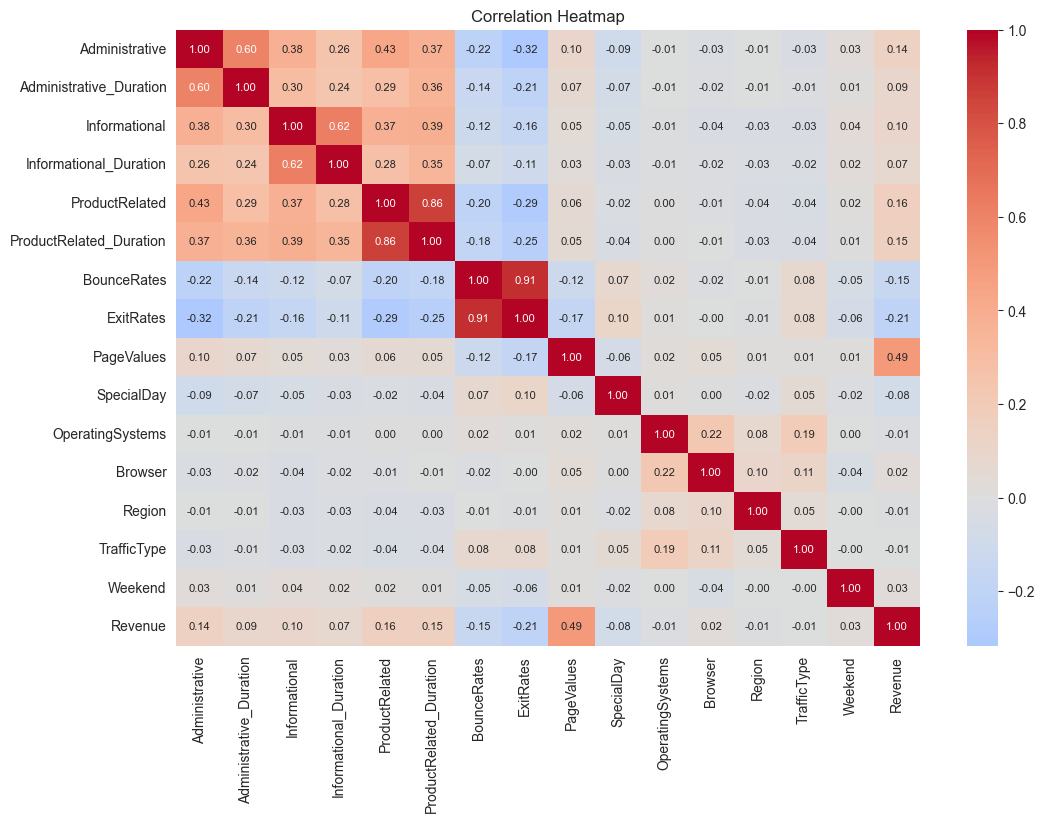

,Revenue
Revenue,1.000
PageValues,0.493
ProductRelated,0.159
ProductRelated_Duration,0.152
Administrative,0.139
Informational,0.095
Administrative_Duration,0.094
Informational_Duration,0.070
Weekend,0.029
Browser,0.024


In [4]:
# correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    raw_df.corr(numeric_only=True), 
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.show()

# correlation with target
raw_target_correlations_table = raw_df.corr(numeric_only=True)
pd.DataFrame(raw_target_correlations_table['Revenue']
             .sort_values(ascending=False)
             .round(3)
            )

### Correlation heatmap
- Strongest linear signal to `Revenue`
  - `PageValues` has the strongest positive linear relationship with `Revenue`.
  - `ExitRates` and `BounceRates` show the clearest negative relationships.

- Predictor overlap
  - Page-count and duration pairs are closely related.
  - `BounceRates` and `ExitRates` also appear to carry overlapping information.

##### Pre-processing decisions
- Watch for multicollinearity in linear models.
- For tree-based models, this overlap is less concerning.
- Coded numeric variables should still be treated as categorical rather than interpreted through correlation strength.

## NA/empty/zero Analysis

In [5]:
# Missing / zero summary table
n = len(raw_df)

# Create masks
na_mask = raw_df.isna()
empty_mask = raw_df.eq("")
zero_mask = raw_df.select_dtypes(include=np.number).eq(0)

# Create summary table
summary_table = pd.DataFrame(index=raw_df.columns)

summary_table["NA Count"] = na_mask.sum()
summary_table["NA %"] = na_mask.mean() * 100

summary_table["Empty String Count"] = empty_mask.sum()
summary_table["Empty String %"] = empty_mask.mean() * 100

summary_table["Zero Count"] = zero_mask.sum().reindex(raw_df.columns, fill_value=0)
summary_table["Zero %"] = (zero_mask.mean() * 100).reindex(raw_df.columns, fill_value=0)

# display 
display(summary_table.round(2))

,NA Count,NA %,Empty String Count,Empty String %,Zero Count,Zero %
Administrative,0,0.0,0,0.0,5768,46.78
Administrative_Duration,0,0.0,0,0.0,5903,47.88
Informational,0,0.0,0,0.0,9699,78.66
Informational_Duration,0,0.0,0,0.0,9925,80.49
ProductRelated,0,0.0,0,0.0,38,0.31
ProductRelated_Duration,0,0.0,0,0.0,755,6.12
BounceRates,0,0.0,0,0.0,5518,44.75
ExitRates,0,0.0,0,0.0,76,0.62
PageValues,0,0.0,0,0.0,9600,77.86
SpecialDay,0,0.0,0,0.0,11079,89.85


### Missingness
- NAs & empties
    - No features contain NAs or empty values, this was expected as noted from source, but checked anyway for best practice.

- Zero inflation
    - `Administrative`, `Administrative_Duration`, `Informational`, and `Informational_Duration` contain many zeros, suggesting that a large share of sessions did not involve those types of pages at all.
    - `PageValues` is also heavily zero-inflated, which is expected since many sessions likely did not progress far enough to generate purchase related data.
    - `SpecialDay` being nearly 90% zero is reasonable, since most browsing sessions would not occur near a holiday or special shopping-related date like black friday.
    - In contrast, `ProductRelated` and `ProductRelated_Duration` contain very few zeros, indicating that most sessions involved product-page interaction.

##### Take away
- The dataset does not deal with missingess, however we can see a trend with sparse behavior among most predictors

## Numeric Variable Analysis

In [6]:
# We don't want to look at numeric categorical features in EDA, they'll be preprocessed later
num_cat_cols = ['SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType'] # numeric categorical features

num_cols = [
    col for col in raw_df.select_dtypes(include=np.number).columns
    if col not in num_cat_cols
]

In [7]:
# Skewness
raw_num_skewness = raw_df[num_cols].skew()

# raw skewness table
raw_num_skewness_table = pd.DataFrame(raw_num_skewness, columns=["Skewness"]).sort_values(by="Skewness", ascending=False)
raw_num_skewness_table

,Skewness
Informational_Duration,7.579185
ProductRelated_Duration,7.263228
PageValues,6.382964
Administrative_Duration,5.615719
ProductRelated,4.341516
Informational,4.036464
BounceRates,2.947855
ExitRates,2.148789
Administrative,1.960357


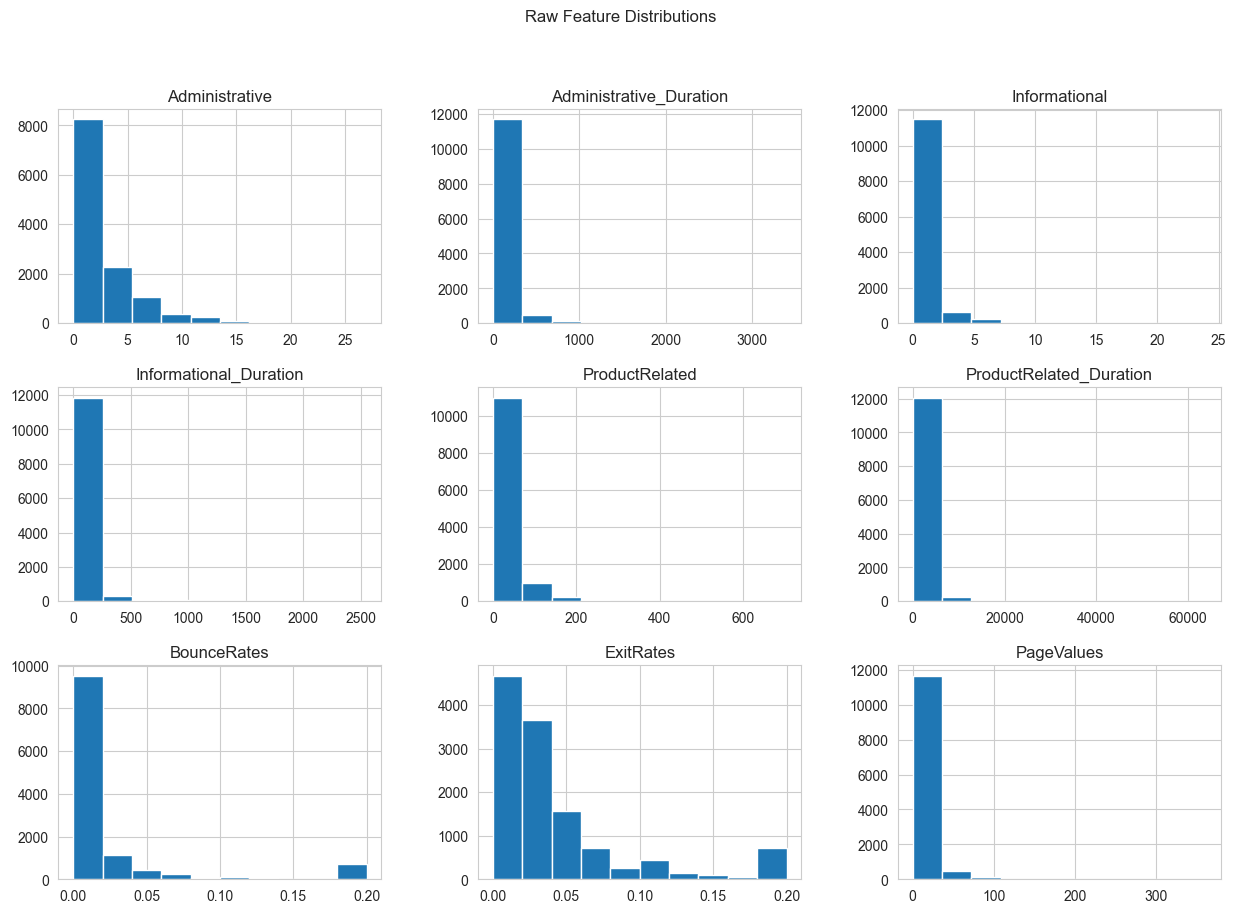

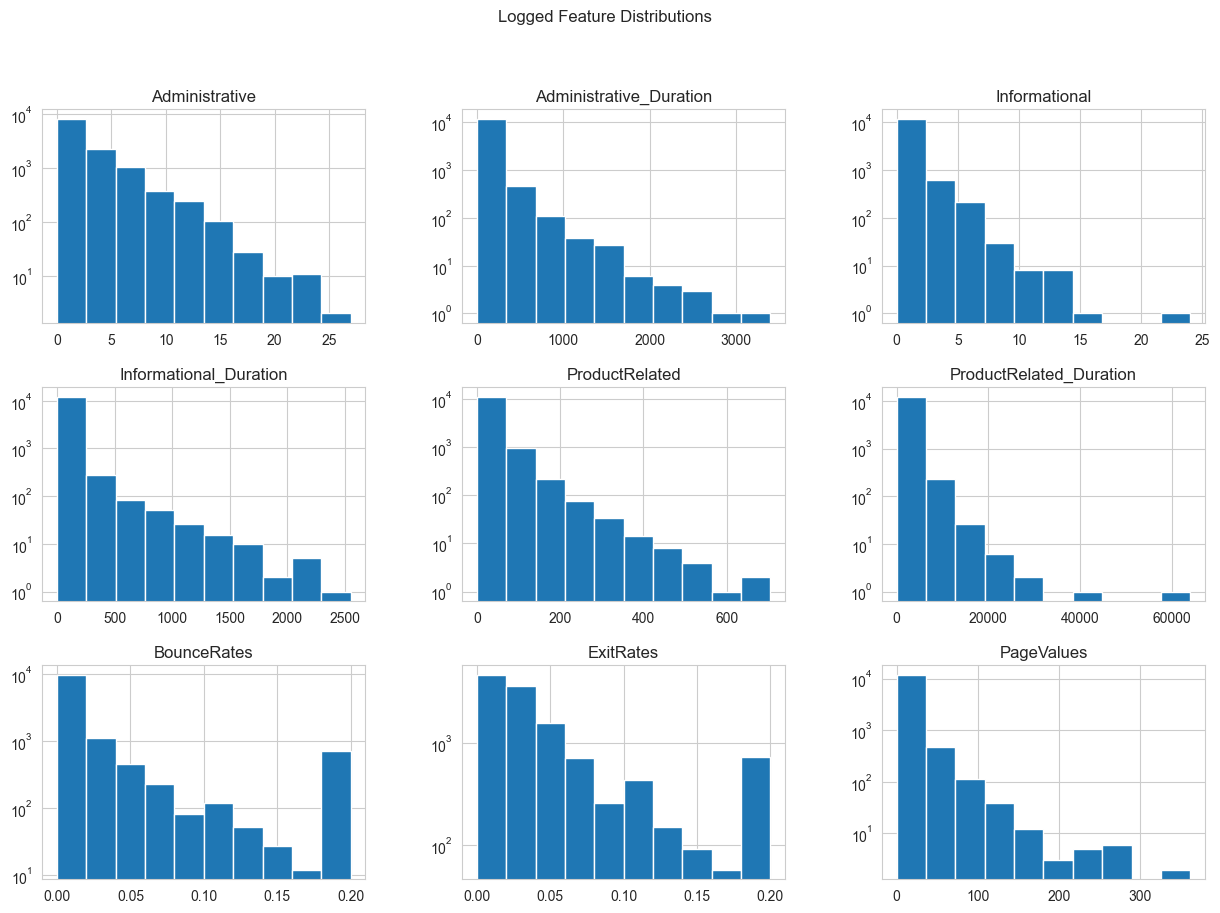

In [8]:
# Feature Distributions
raw_df[num_cols].hist(figsize=(15,10))
plt.suptitle("Raw Feature Distributions")
plt.show()

# logged distribution check
raw_df[num_cols].hist(figsize=(15,10), log=True)
plt.suptitle("Logged Feature Distributions")
plt.show()

### Raw vs log-transformed distributions
- Raw vs transformed shape
  - The raw duration variables and `PageValues` are heavily compressed near 0 with long right tails.
  - After `log1p()`, the non-zero portion becomes much easier to inspect.

- Transformation insight
  - `ProductRelated_Duration` improves the most after transformation.
  - `Administrative_Duration`, `Informational_Duration`, and `PageValues` still retain a large spike at 0.

- Zero inflation
  - `SpecialDay`, `Informational`, `Informational_Duration`, and `PageValues` contain many zeros.

#### Pre-processing decisions:
- `log1p()` is a reasonable option for these variables.
- Zeros should be kept as valid values.
- A separate binary indicator for any activity may be worth testing later for variables with many zeros.

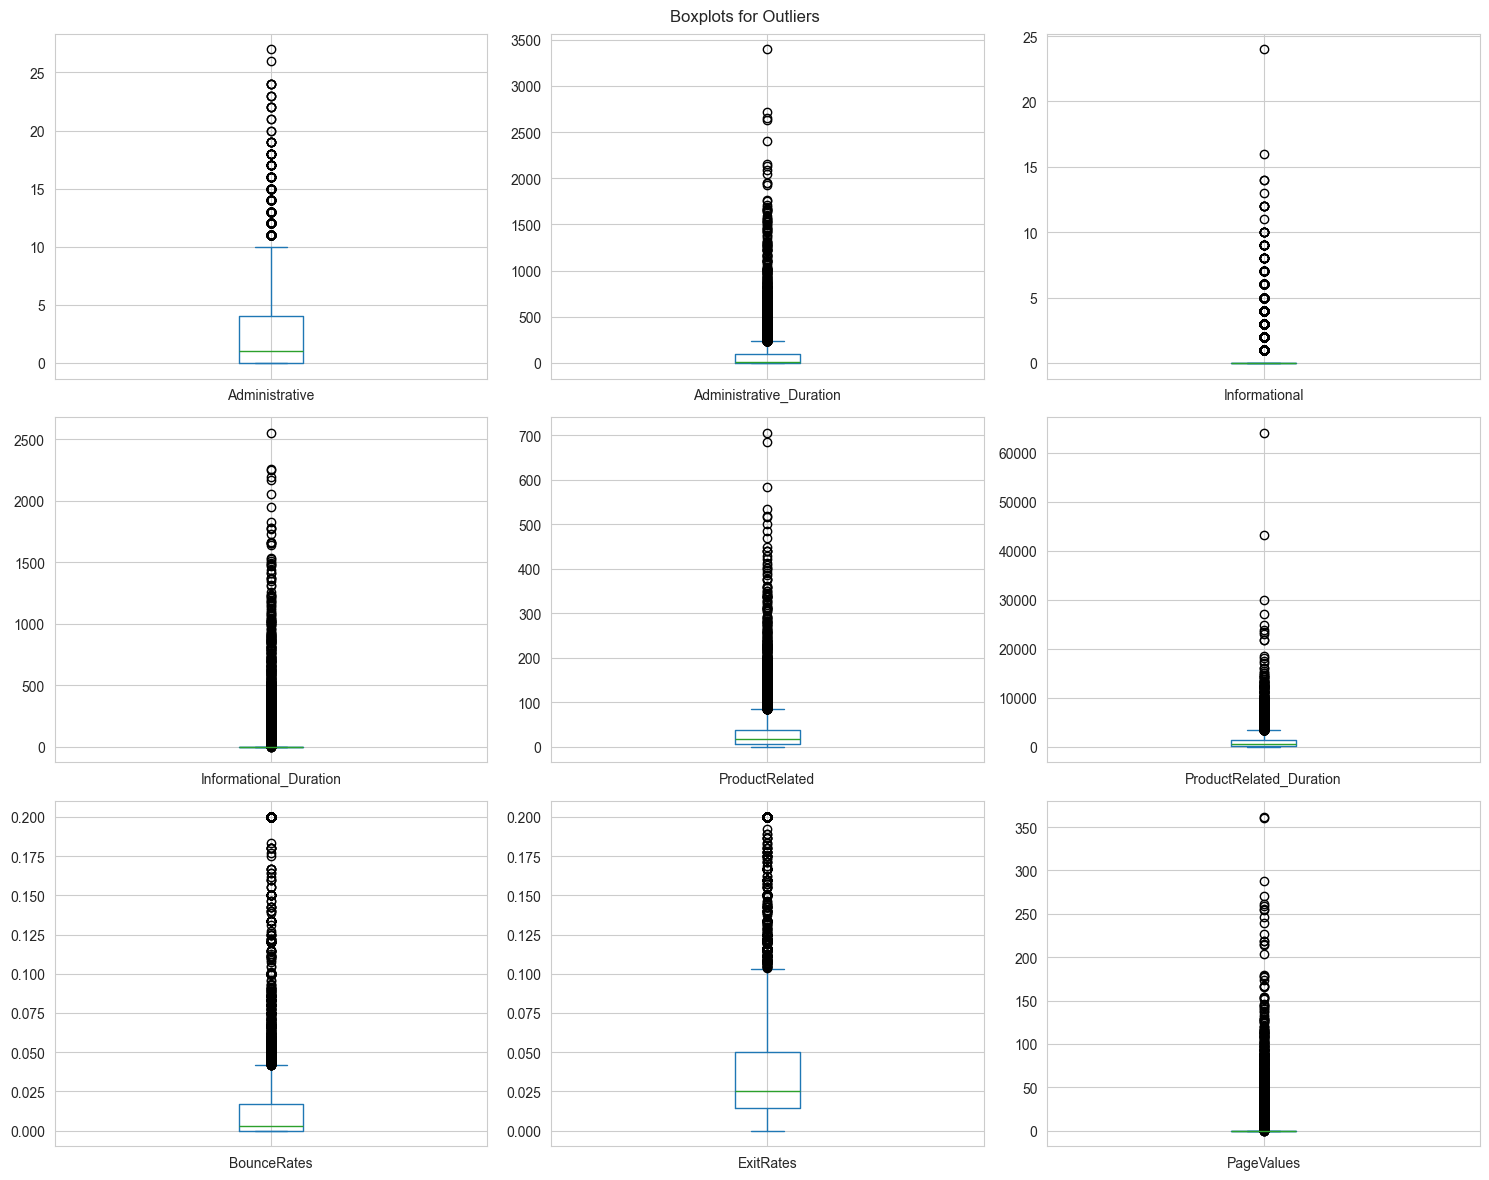

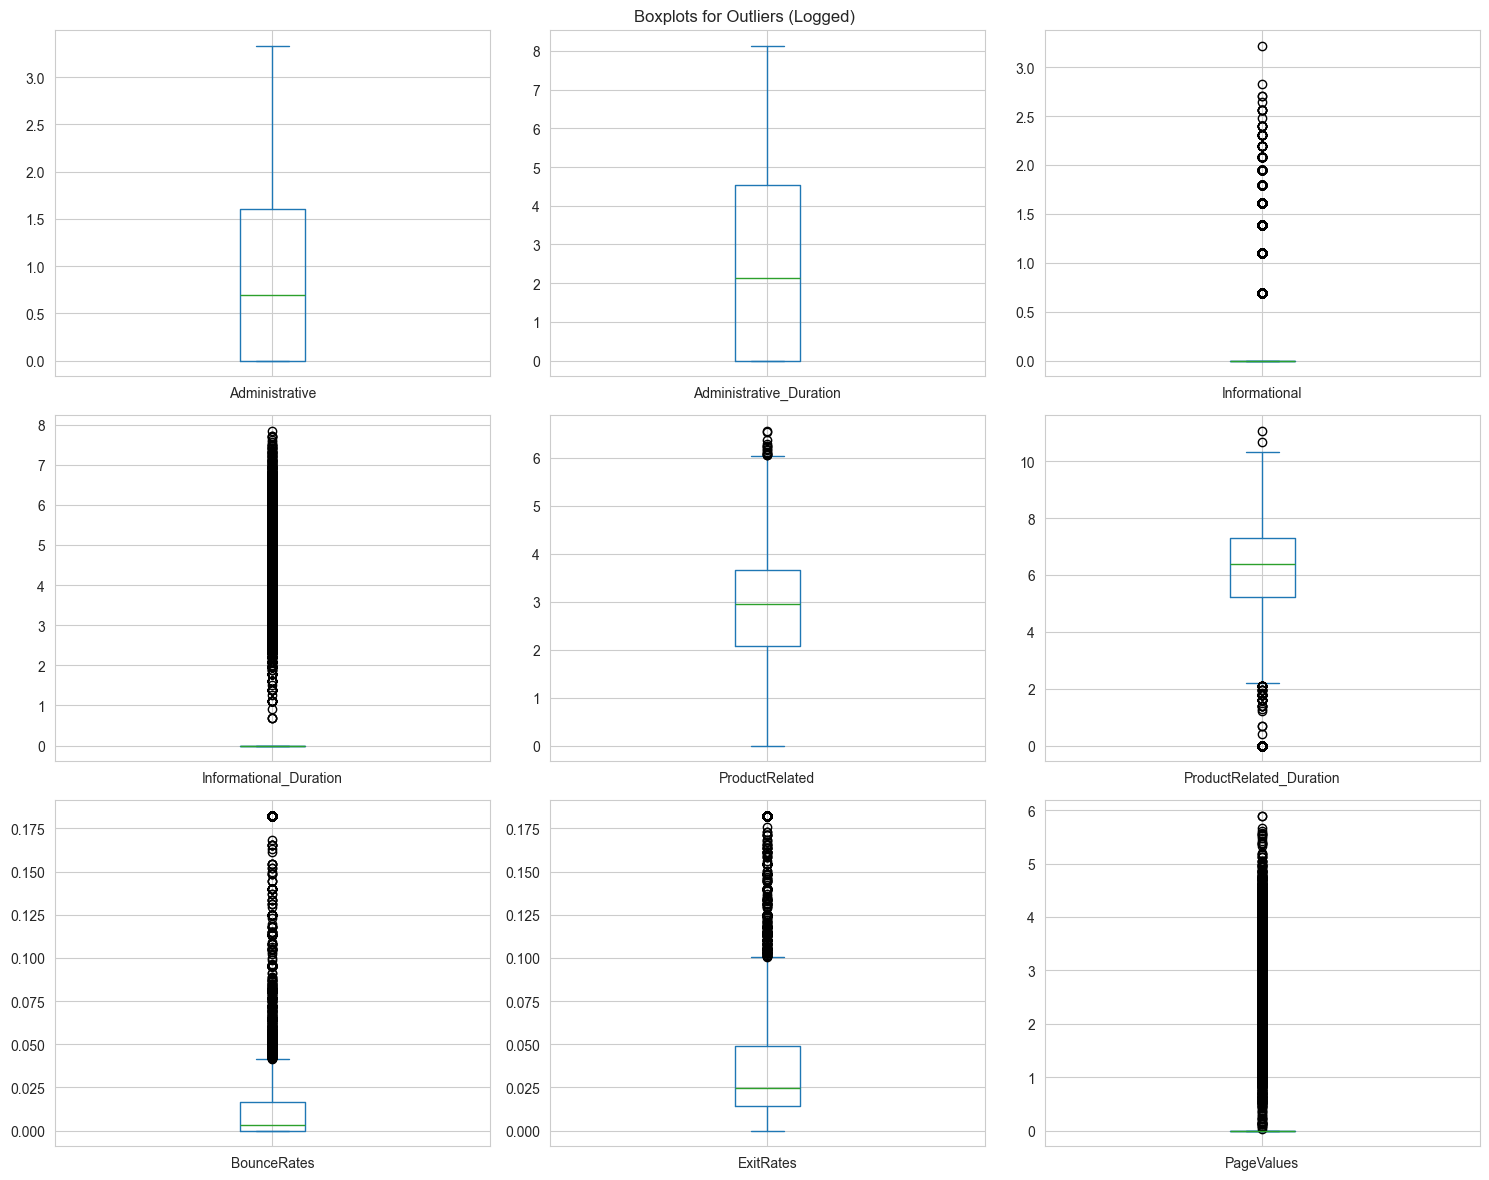

In [9]:
# Boxplots for outliers
raw_df[num_cols].plot(
    kind='box',
    subplots=True,
    layout=(-1, 3),
    figsize=(15, 12),
    sharex=False,
    sharey=False
)

plt.suptitle("Boxplots for Outliers")
plt.tight_layout()
plt.show()

# Boxplots for outliers (logged)
np.log1p(raw_df[num_cols]).plot(
    kind='box',
    subplots=True,
    layout=(-1, 3),
    figsize=(15, 12),
    sharex=False,
    sharey=False
)

plt.suptitle("Boxplots for Outliers (Logged)")
plt.tight_layout()
plt.show()

### Boxplots
- Outliers
    - Most boxplots are heavily influenced by zero inflation, which compresses much of the data near 0.
    - `Administrative` and `Administrative_Duration`, as well as `ProductRelated` and `ProductRelated_Duration`, become easier to inspect after log transformation.

- Take away
    - Apparent outliers are partly a result of strong right skew and many zero values.
    - This further supports testing both raw and log-transformed versions in modeling.

## Categorical Variable Analysis

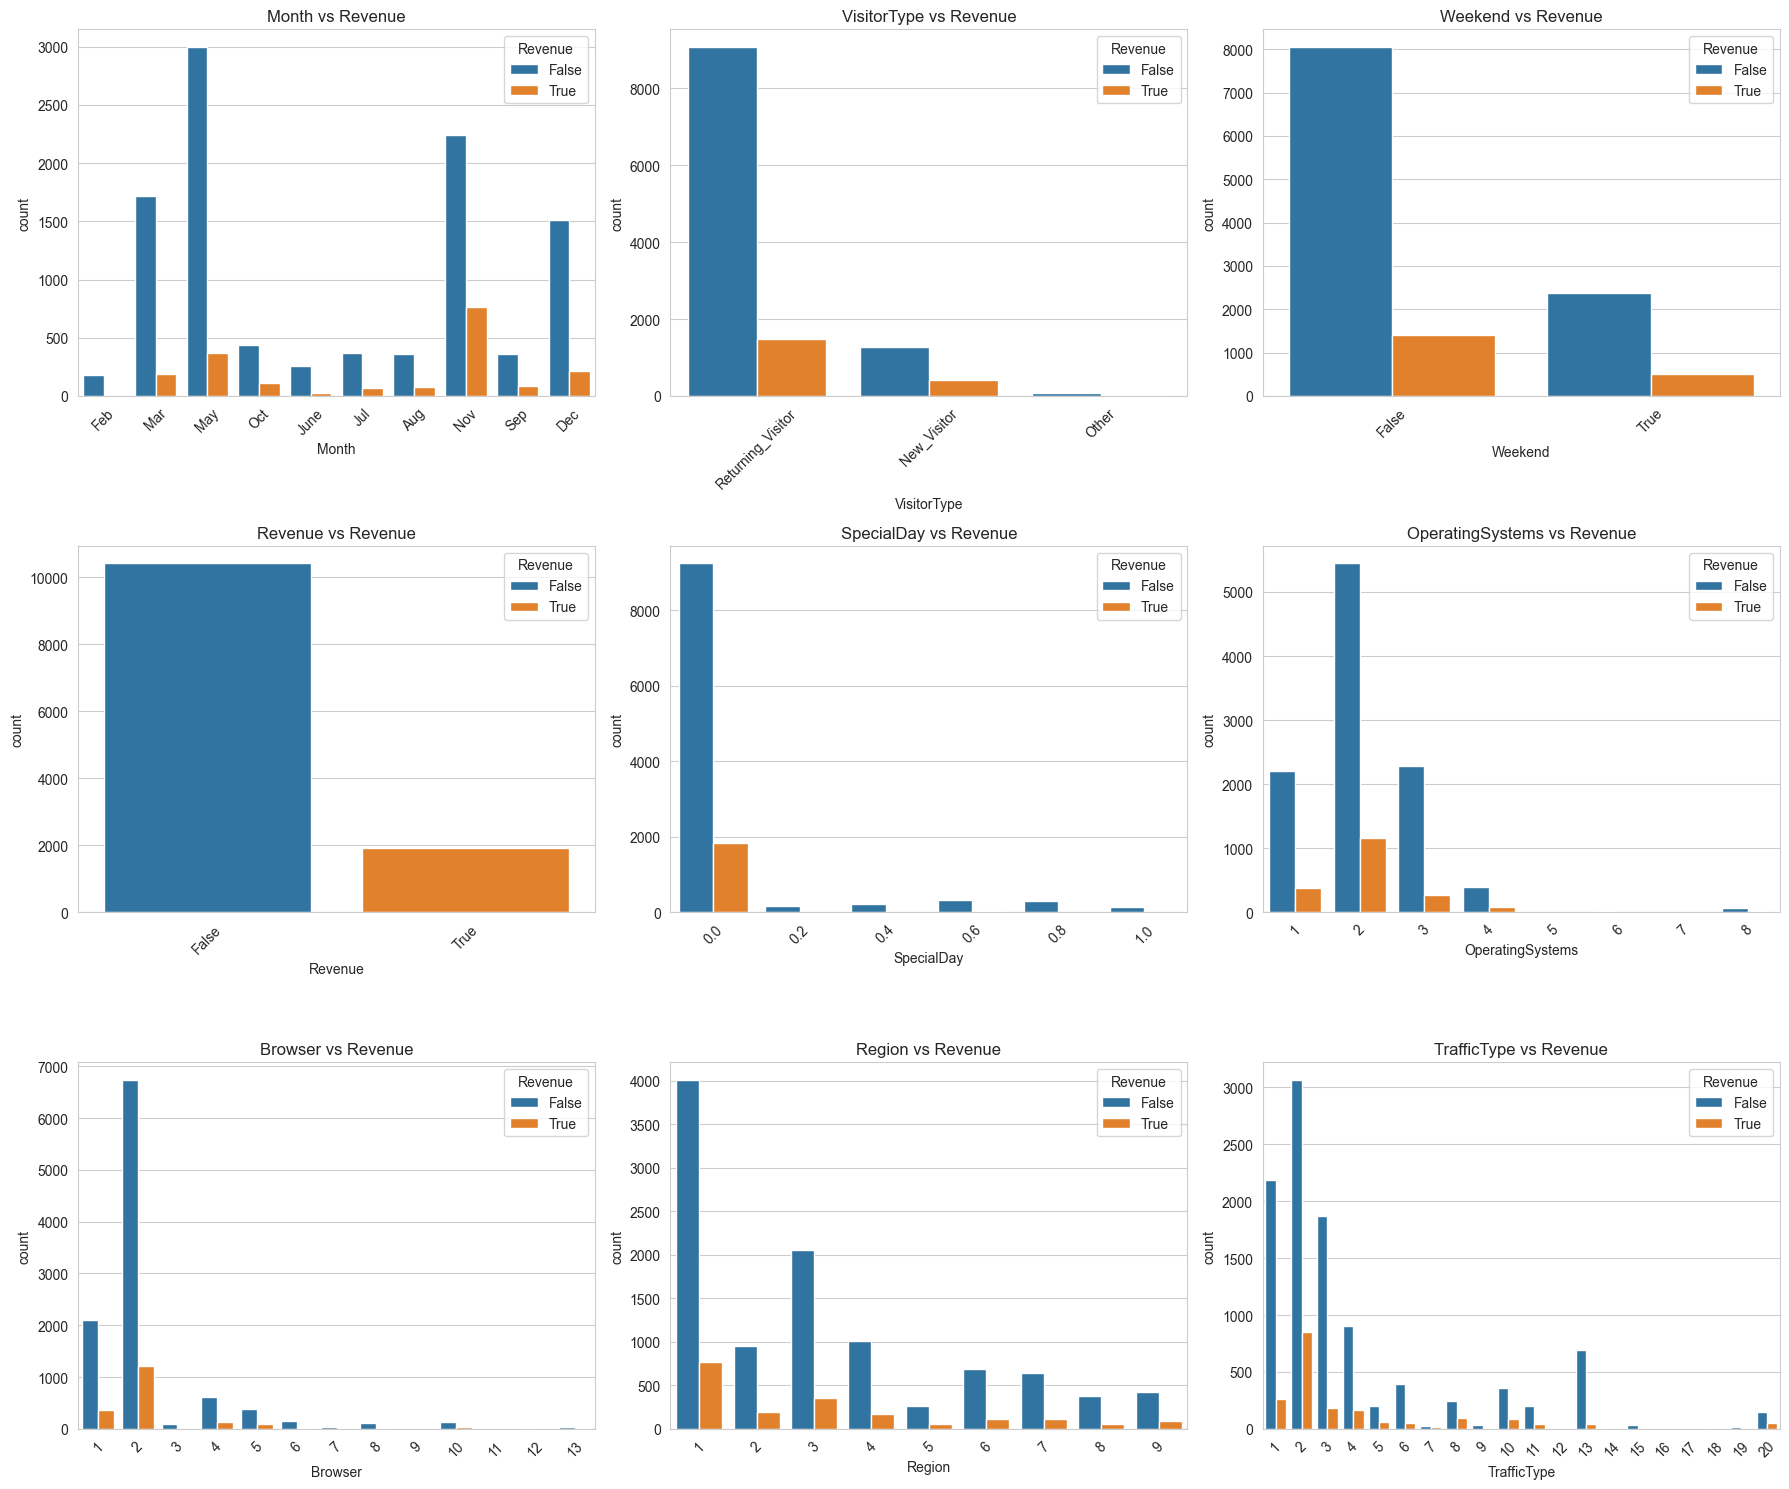


Month purchase rate:
Month
Nov     0.253502
Oct     0.209472
Sep     0.191964
Aug     0.175520
Jul     0.152778
Dec     0.125072
May     0.108502
June    0.100694
Mar     0.100682
Feb     0.016304
Name: Revenue, dtype: float64

VisitorType purchase rate:
VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

Weekend purchase rate:
Weekend
True     0.173989
False    0.148911
Name: Revenue, dtype: float64

Revenue purchase rate:
Revenue
True     1.0
False    0.0
Name: Revenue, dtype: float64

SpecialDay purchase rate:
SpecialDay
0.0    0.165268
0.6    0.082621
0.2    0.078652
1.0    0.064935
0.4    0.053498
0.8    0.033846
Name: Revenue, dtype: float64

OperatingSystems purchase rate:
OperatingSystems
8    0.215190
4    0.177824
2    0.174973
5    0.166667
1    0.146615
7    0.142857
6    0.105263
3    0.104892
Name: Revenue, dtype: float64

Browser purchase rate:
Browser
12    0.300000
13    0.262295
10    0.

In [10]:
# Identify categorical columns
cat_cols = raw_df.select_dtypes(include=['object', 'bool']).columns.tolist() + num_cat_cols

# Set subplot grid shape
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

# Create subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Count plots for each categorical feature vs Revenue
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=raw_df, x=col, hue='Revenue', ax=ax)
    ax.set_title(f"{col} vs Revenue")
    ax.tick_params(axis='x', rotation=45)

# Remove any unused subplot axes
for ax in axes[len(cat_cols):]:
    fig.delaxes(ax)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

# Purchase rate by category
for col in cat_cols:
    print(f"\n{col} purchase rate:")
    print(raw_df.groupby(col)['Revenue'].mean().sort_values(ascending=False))

### Categoricals

- Behavioral trends
    - `Month` shows some seasonal differences, with stronger purchase rates in months like November and October. But contradictory with March and May.
    - `VisitorType` suggests New_Visitor sessions purchase at a higher rate than Returning_Visitor sessions.
    - `Weekend` shows only a small difference.

- Numerical encoded predictors
    - `SpecialDay` acts more like a closeness metric than a standard numeric variable.
    - `OperatingSystems`, `Browser`, `Region`, and `TrafficType` are coded categories, but are not strongly interpretable on their own.

- Take away
    - `Month`, `VisitorType`, and `Weekend` are the most interpretable categorical predictors.
    - The numeric-coded categorical variables may still help prediction, but add little behavioral insight without further documentation.

---

# Pre-processing

In [ ]:
# Convert target to binary
df = raw_df.copy()
df['Revenue'] = df['Revenue'].astype(int)

# List of variables lacking documentation
drop_cols = ['SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

# drop columns from df
df.drop(columns=drop_cols, inplace=True)

# check columns after dropping
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'Month', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [12]:
# Separate Features and Target
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Identify Feature Types
categorical_cols = ['Month', 'VisitorType', 'Weekend']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessing Pipelines
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Train/Validation/Test Split
# First split (train + temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split (validation + test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (8631, 12)
Validation: (1849, 12)
Test: (1850, 12)


---

# Modelling

Baseline Accuracy: 0.8453217955651704
Baseline F1: 0.0
Baseline Confusion Matrix:
[[1563    0]
 [ 286    0]]


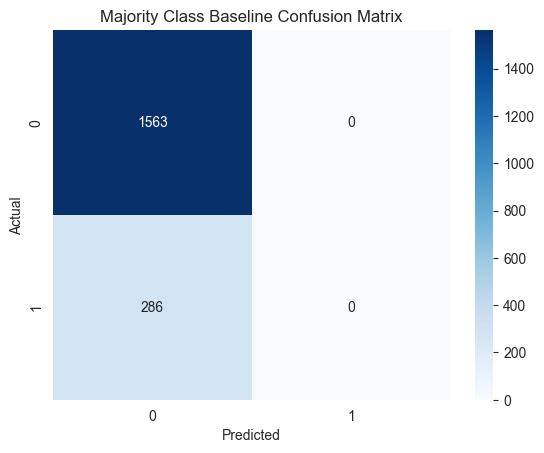

In [13]:
# Baseline Model 1: Majority Class
majority_class = y_train.mode()[0]
y_pred_baseline = np.full_like(y_val, majority_class)

print("Baseline Accuracy:", accuracy_score(y_val, y_pred_baseline))
print("Baseline F1:", f1_score(y_val, y_pred_baseline))

cm_majority_baseline = confusion_matrix(y_val, y_pred_baseline)
print("Baseline Confusion Matrix:")
print(cm_majority_baseline)

sns.heatmap(cm_majority_baseline, annot=True, fmt='d', cmap='Blues')
plt.title("Majority Class Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1563
           1       0.76      0.34      0.47       286

    accuracy                           0.88      1849
   macro avg       0.82      0.66      0.70      1849
weighted avg       0.87      0.88      0.86      1849

ROC-AUC: 0.8916307620722208
Confusion Matrix:
[[1532   31]
 [ 189   97]]


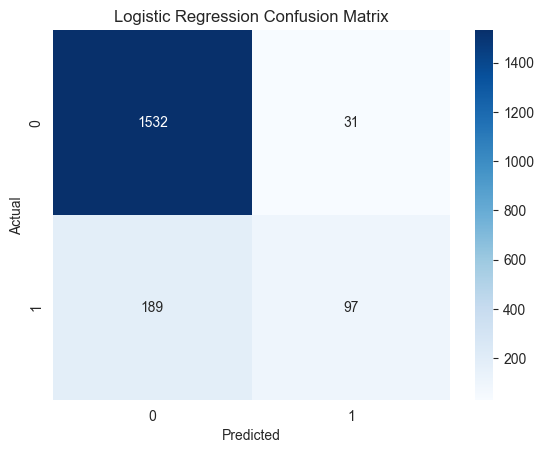

In [14]:
# Baseline Model 2: Logistic Regression
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_val)
y_prob = log_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

cm_log_baseline = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm_log_baseline)

sns.heatmap(cm_log_baseline, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Baseline models
- Majority Class
    - Accuracy is high due to the target imbalance.
    - F1 is 0 since the model never predicts a purchase.

- Logistic Regression
    - F1 class 0: 0.93, identify non-purchase sessions well
    - F1 class 1: 0.47, weaker at identifying purchase sessions
    - ROC-AUC: 0.892, can separate the two classes reasonably well
    - The default cutoff still produces weak sensitivity for the minority class

- Take away
    - There is real predictive signal in the dataset beyond class imbalance
    - Logistic regression works as a meaningful interpretable baseline, but the purchase class remains harder to capture

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1563
           1       0.68      0.50      0.58       286

    accuracy                           0.89      1849
   macro avg       0.79      0.73      0.76      1849
weighted avg       0.88      0.89      0.88      1849

Confusion Matrix:
[[1494   69]
 [ 142  144]]


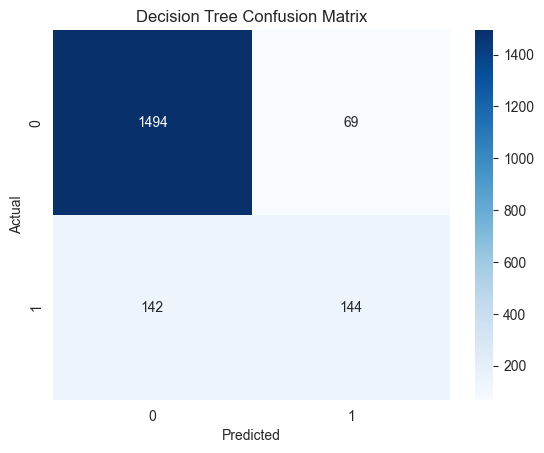

In [15]:
# Decision Tree
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5))
])

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_val)
print(classification_report(y_val, y_pred))

cm_dt = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Decision Tree
- Metrics
    - F1 class 0: 0.93, the model still identifies non-purchase sessions well
    - F1 class 1: 0.58, this is an improvement over logistic regression for purchase sessions
    - Accuracy: 0.89, slightly higher overall performance than the baseline logistic model
    - The tree likely captures simple nonlinear splits and threshold-based behavior missed by logistic regression

- Take away
    - The improvement in class 1 performance suggests purchase behavior is not purely linear
    - A decision tree adds interpretability through rule-based splits while improving minority-class detection

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1563
           1       0.75      0.52      0.62       286

    accuracy                           0.90      1849
   macro avg       0.84      0.75      0.78      1849
weighted avg       0.89      0.90      0.89      1849

ROC-AUC: 0.9128580951997458
Confusion Matrix:
[[1514   49]
 [ 136  150]]


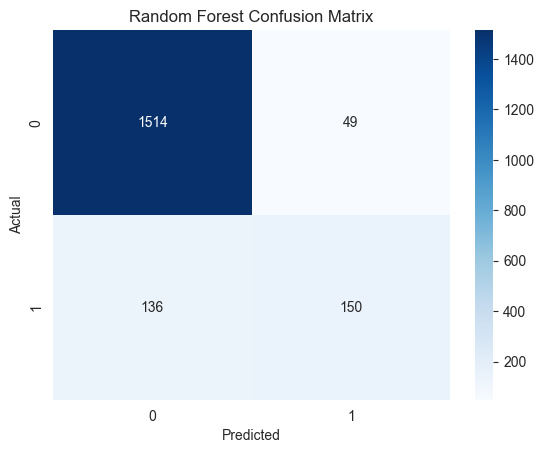

In [16]:
# Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

cm_rf = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest
- Metrics
    - F1 class 0: 0.94, the model continues to classify non-purchase sessions very well
    - F1 class 1: 0.60, a small improvement over the decision tree for purchase sessions
    - ROC-AUC: 0.916, stronger class separation than the earlier models
    - The forest improves performance by combining many trees, reducing the instability of a single tree while capturing more complex structure

- Take away
    - The gain over the decision tree is modest, but it suggests added complexity is helping
    - Purchase behavior likely contains nonlinear patterns that are better captured through an ensemble rather than one fixed tree

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1563
           1       0.70      0.56      0.62       286

    accuracy                           0.90      1849
   macro avg       0.81      0.76      0.78      1849
weighted avg       0.89      0.90      0.89      1849

ROC-AUC: 0.9205065567829483
Confusion Matrix:
[[1496   67]
 [ 127  159]]


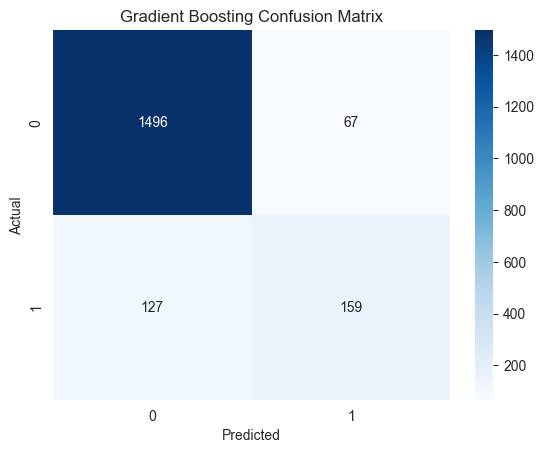

In [17]:
# Gradient Boosting
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())
])

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_val)
y_prob = gb_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

cm_gb = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm_gb)

sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Gradient Boosting
- Metrics
    - F1 class 0: 0.94, the model continues to classify non-purchase sessions very well
    - F1 class 1: 0.62, the strongest performance so far for purchase sessions
    - ROC-AUC: 0.920, slightly better class separation than the random forest
    - Boosting improves by sequentially focusing on mistakes made by earlier trees, which likely helps capture harder purchase-session patterns

- Take away
    - The improvement in class 1 performance suggests boosting is better at learning the minority-class structure
    - This supports the idea that purchase behavior contains more complex patterns than a single tree or simple linear boundary can capture

              precision    recall  f1-score   support

           0       0.91      0.96      0.94      1563
           1       0.72      0.49      0.58       286

    accuracy                           0.89      1849
   macro avg       0.81      0.73      0.76      1849
weighted avg       0.88      0.89      0.88      1849

ROC-AUC: 0.8557619603684863
Confusion Matrix:
[[1508   55]
 [ 147  139]]


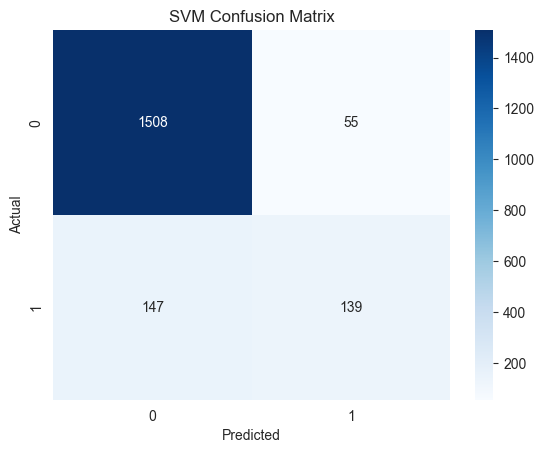

In [18]:
# Suppport Vector Machine
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True))
])

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_val)
y_prob = svm_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

cm_svm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm_svm)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Support Vector Machine
- Metrics
    - F1 class 0: 0.94, the model still identifies non-purchase sessions well
    - F1 class 1: 0.58, weaker than the random forest and gradient boosting for purchase sessions
    - ROC-AUC: 0.856, lower class separation than the earlier models
    - The SVM performs reasonably, but does not appear to capture the purchase-session structure as effectively as the tree-based ensembles

- Take away
    - This suggests the nonlinear boundary used by SVM is not as well matched to this dataset as the ensemble tree methods
    - More complexity does not automatically mean better performance

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1564
           1       0.74      0.58      0.65       286

    accuracy                           0.90      1850
   macro avg       0.84      0.77      0.80      1850
weighted avg       0.90      0.90      0.90      1850

Test ROC-AUC: 0.9281808345107578
Test Confusion Matrix:
[[1507   57]
 [ 120  166]]


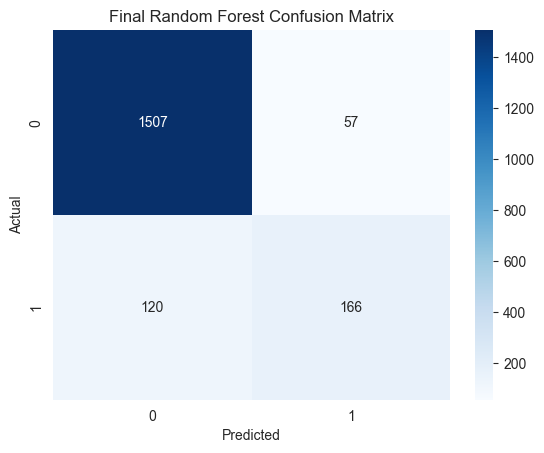

In [20]:
# Final Evaluation on Test Set
final_model = rf_model  # choose best model

final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))

cm_rf_test = confusion_matrix(y_test, y_test_pred)
print("Test Confusion Matrix:")
print(cm_rf_test)

sns.heatmap(cm_rf_test, annot=True, fmt='d', cmap='Blues')
plt.title("Final Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Final Random Forest
- Metrics 
    - F1 class 0: 0.95, the model identifies non-purchase sessions very well
    - F1 class 1: 0.66, the strongest purchase-session performance in the final evaluation
    - Test ROC-AUC: 0.930, strong class separation on unseen data

- Take away
    - The random forest generalizes well to the test set
    - The improvement on class 1 suggests the model captures meaningful nonlinear session behavior related to purchase outcomes

---

### Future Directions

- Additional models
    - XGBoost, LightGBM, or CatBoost could be tested as other strong boosting methods.
    - A standard neural network could be attempted for improvement.

- Model tuning
    - Hyperparameter tuning may improve the current random forest more than switching immediately to entirely new model family.
    - Threshold tuning is worth testing since the default cutoff may not be optimal for class 1 F1 or recall.
    - Class weighting or imbalance-focused tuning could help improve purchase-session sensitivity.

- Feature transformations
    - Log transformation is still worth testing for strongly right-skewed variables, especially the duration variables and PageValues.
    - This may help linear-type models more than tree-based models, but is still a reasonable comparison to make.
    - With zero-inflation, we could switch features to binary for activity vs no-activity.

- Feature reduction
    - Some variables may be redundant, especially the page-count and duration pairs, as well as BounceRates and ExitRates.
    - Reduction methods could test whether a smaller feature set keeps similar performance while improving interpretability.
    - This can be done through correlation review, model-based importance, or regularization-based selection.

#### Take away
- The most useful next steps are likely tuning, threshold adjustment, log transformation tests, and feature reduction.

---